In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Set paths
base_dir = '/content/drive/MyDrive/laby'  # Change if needed
excel_path = os.path.join(base_dir, 'Data-Laby 5-12.xlsx')
image_dir = os.path.join(base_dir, 'images')

# Load Excel
df = pd.read_excel(excel_path)

# If your Excel doesn't have filenames, generate them (1.jpg to 20.jpg)
df['filename'] = [f"{i}.jpg" for i in range(1, 21)]
df['filepath'] = df['filename'].apply(lambda x: os.path.join(image_dir, x))

# Keep relevant columns
df = df[['filepath', 'LC', 'MD', 'DP', 'TT']]


In [ ]:
train_df, test_df = train_test_split(df, test_size=5, random_state=42)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


In [ ]:
def preprocess_image_rgb(image_path):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    img = load_img(image_path, target_size=(224, 224))  # RGB by default
    img = img_to_array(img) / 255.0
    return img

X_train_rgb = np.array([preprocess_image_rgb(p) for p in train_df['filepath']])
X_test_rgb = np.array([preprocess_image_rgb(p) for p in test_df['filepath']])

y_train_scaled = scaler.fit_transform(train_df[['LC', 'MD']].values)
y_test_scaled = scaler.transform(test_df[['LC', 'MD']].values)


Load Pretrained MobileNetV2 and Add a Regression Head

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D

# Load base MobileNetV2 without the top classifier
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze weights for transfer learning

# Add custom regression head
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(2, activation='linear')(x)  # Output: LC and MD
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,338 (9.27 MB)

 Trainable params: 172,354 (673.26 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train the Model on Maze Data

In [ ]:
history = model.fit(
    X_train_rgb, y_train_scaled,
    epochs=50,
    batch_size=4,
    validation_data=(X_test_rgb, y_test_scaled)
)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.6694 - mae: 0.6647 - val_loss: 0.1484 - val_mae: 0.3307
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - loss: 0.2224 - mae: 0.3651 - val_loss: 0.0925 - val_mae: 0.2264
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - loss: 0.1106 - mae: 0.2850 - val_loss: 0.1163 - val_mae: 0.2725
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.0682 - mae: 0.1734 - val_loss: 0.0581 - val_mae: 0.1721
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0764 - mae: 0.1868 - val_loss: 0.0784 - val_mae: 0.2114
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0350 - mae: 0.1395 - val_loss: 0.0635 - val_mae: 0.2052
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0258 - mae: 0.1254 - val_loss: 0.0515 - val_mae: 0.1920
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 0.0254 - mae: 0.1230 - val_loss: 0.0728 - val_mae: 0.2182
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - loss: 0.0169 - mae: 0.

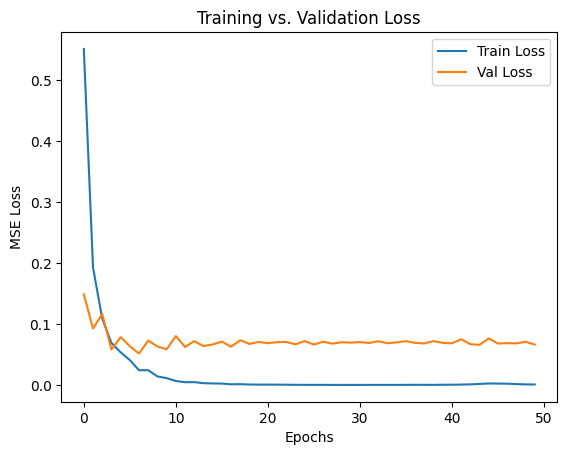

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()


 Predict and Evaluate the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on test set
y_pred_scaled = model.predict(X_test_rgb)
y_pred = scaler.inverse_transform(y_pred_scaled)  # Convert back to original LC/MD scale

# Separate values for analysis
true_lc, true_md = y_test_scaled[:, 0], y_test_scaled[:, 1]
pred_lc, pred_md = y_pred_scaled[:, 0], y_pred_scaled[:, 1]

# Unscale ground truth to compare with unscaled predictions
true_lc_unscaled = scaler.inverse_transform(y_test_scaled)[:, 0]
true_md_unscaled = scaler.inverse_transform(y_test_scaled)[:, 1]
pred_lc_unscaled = y_pred[:, 0]
pred_md_unscaled = y_pred[:, 1]

# ROUND LC if it's expected to be integer
pred_lc_rounded = np.round(pred_lc_unscaled)

# 📊 Evaluate LC
print("📏 LC Evaluation:")
print("MAE:", mean_absolute_error(true_lc_unscaled, pred_lc_rounded))
print("MSE:", mean_squared_error(true_lc_unscaled, pred_lc_rounded))
print("R²:", r2_score(true_lc_unscaled, pred_lc_rounded))

# 📊 Evaluate MD
print("\n📏 MD Evaluation:")
print("MAE:", mean_absolute_error(true_md_unscaled, pred_md_unscaled))
print("MSE:", mean_squared_error(true_md_unscaled, pred_md_unscaled))
print("R²:", r2_score(true_md_unscaled, pred_md_unscaled))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
📏 LC Evaluation:
MAE: 1.6000000000000003
MSE: 3.2000000000000015
R²: 0.6261682242990653

📏 MD Evaluation:
MAE: 1.338454683125019
MSE: 2.5505582352777183
R²: -0.1808139978137584


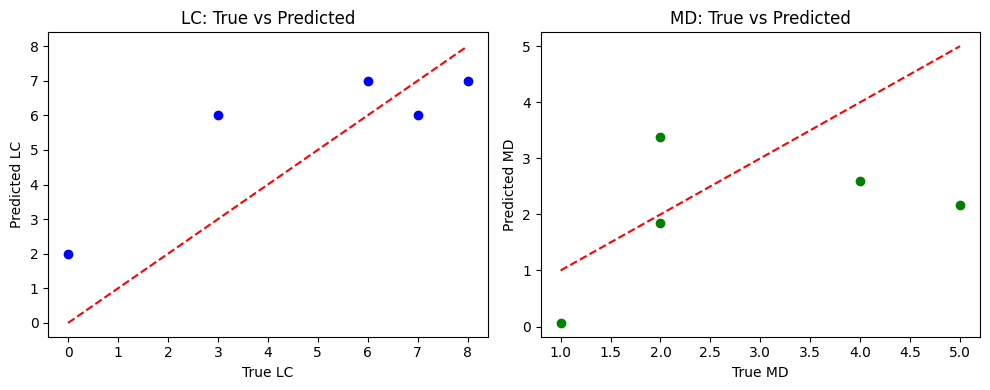

In [ ]:
plt.figure(figsize=(10, 4))

# LC Plot
plt.subplot(1, 2, 1)
plt.scatter(true_lc_unscaled, pred_lc_rounded, color='blue')
plt.plot([min(true_lc_unscaled), max(true_lc_unscaled)],
         [min(true_lc_unscaled), max(true_lc_unscaled)],
         color='red', linestyle='--')
plt.xlabel("True LC")
plt.ylabel("Predicted LC")
plt.title("LC: True vs Predicted")

# MD Plot
plt.subplot(1, 2, 2)
plt.scatter(true_md_unscaled, pred_md_unscaled, color='green')
plt.plot([min(true_md_unscaled), max(true_md_unscaled)],
         [min(true_md_unscaled), max(true_md_unscaled)],
         color='red', linestyle='--')
plt.xlabel("True MD")
plt.ylabel("Predicted MD")
plt.title("MD: True vs Predicted")

plt.tight_layout()
plt.show()
